vaja 11. Spektrometer

Pri tej vaji smo meriili spektre svetlobnih virov in prepustne spektre raznih materijalov in filtrov.

✓ Loaded meritve/ref.csv
✓ Loaded meritve/3blue.csv


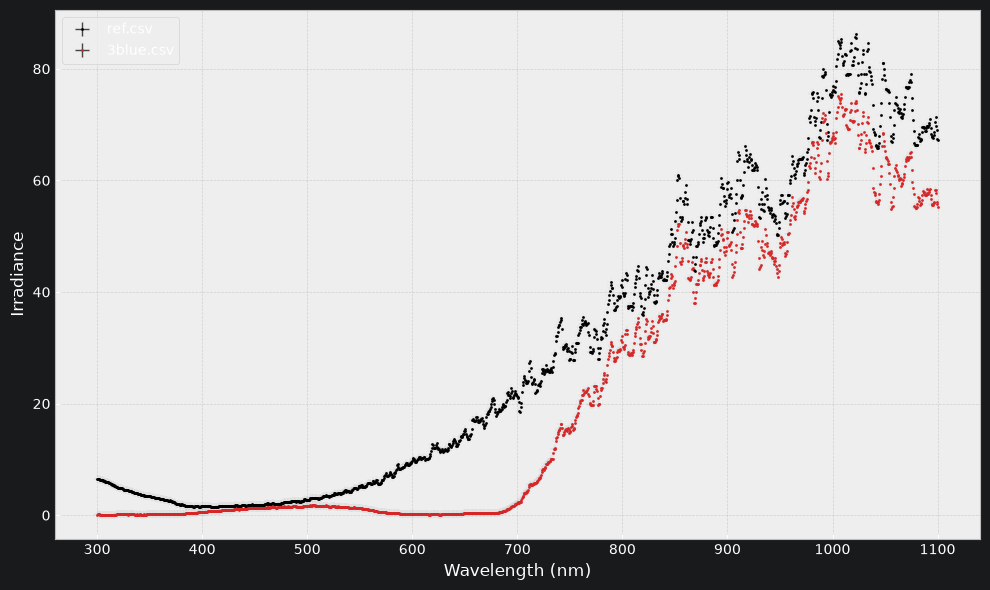

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

plt.style.use('bmh')

filenames = ["meritve/ref.csv", "meritve/3blue.csv"]

#rdeca je ref
colors = ['#000000', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']

fig, ax = plt.subplots(figsize=(10, 6))

for idx, filename in enumerate(filenames):
    try:
        with open(filename, "r") as f:
            lines = f.readlines()

        header_idx = next(i for i, line in enumerate(lines) if "Index" in line and "X:" in line)
        df = pd.read_csv(filename,
                          skiprows=header_idx,
                          sep="\t",
                          decimal=",",
                          nrows=1368)

        x = df.iloc[:, 1].to_numpy()
        y = df.iloc[:, 2].to_numpy()

        color = colors[idx % len(colors)]
        ax.errorbar(
            x, y,
            yerr=0,
            xerr=0,
            fmt='o',
            markersize=2,
            color=color,
            ecolor='#444444',
            elinewidth=1,
            capsize=3,
            capthick=1,
            markeredgewidth=0.01,
            linestyle='none',
            label=filename.split('/')[-1]
        )

        print(f"✓ Loaded {filename}")

    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")

plt.legend()
plt.xlabel(r"Wavelength (nm)")
plt.ylabel(r"Irradiance")
plt.tight_layout()
plt.show()

✓ Loaded [0] meritve/3RG.csv
✓ Loaded [1] meritve/3red.csv
✓ Loaded [2] meritve/3green.csv
✓ Multiplied [1] × [2]


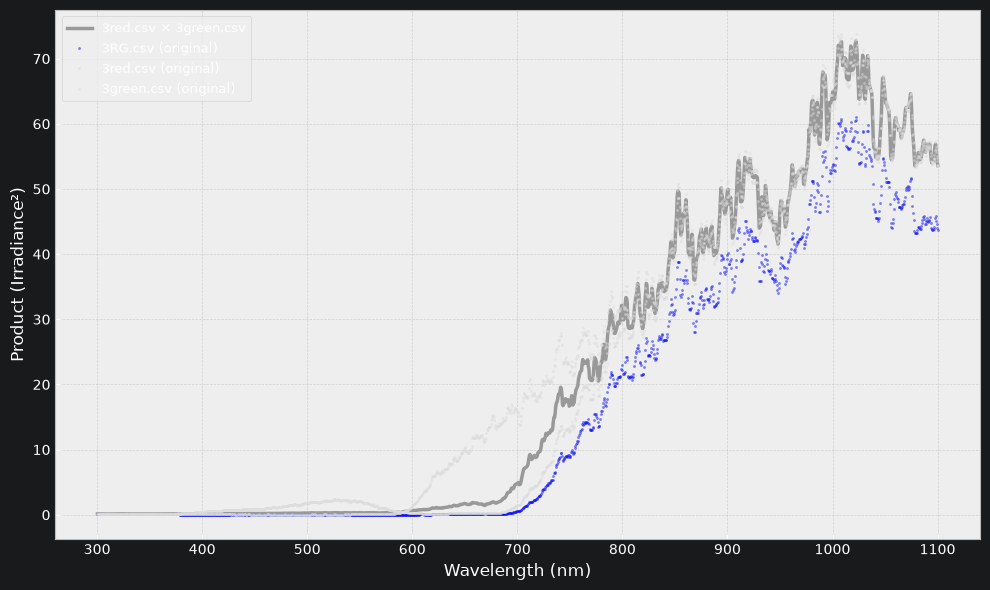

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

plt.style.use('bmh')

filenames = ["meritve/3RG.csv", "meritve/3red.csv", "meritve/3green.csv"]

#multiply filenames[0] * filenames[1]
multiply_indices = [(1, 2)]  # kere zmnozi

colors = ['#070bfc', '#dddddd', '#dddddd', '#dddddd', '#dddddd', '#dddddd']

def load_spectrum(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_idx = next(i for i, line in enumerate(lines) if "Index" in line and "X:" in line)

    df = pd.read_csv(filename,
                      skiprows=header_idx,
                      sep="\t",
                      decimal=",",
                      nrows=1368)

    x = df.iloc[:, 1].to_numpy()
    y = df.iloc[:, 2].to_numpy()
    return x, y

def multiply_spectra(x1, y1, x2, y2):
    f_interp = interp1d(x2, y2, kind='linear', fill_value='extrapolate')
    y2_interp = f_interp(x1)

    # Multiply
    y_product = np.sqrt(y1 * y2_interp)
    return x1, y_product

# Load all spectra
spectra = {}
for idx, filename in enumerate(filenames):
    try:
        x, y = load_spectrum(filename)
        spectra[idx] = {'x': x, 'y': y, 'name': filename.split('/')[-1]}
        print(f"✓ Loaded [{idx}] {filename}")
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all original spectra
for idx, data in spectra.items():
    color = colors[idx % len(colors)]
    ax.errorbar(
        data['x'], data['y'],
        fmt='o',
        markersize=2,
        color=color,
        elinewidth=1,
        capsize=3,
        capthick=1,
        markeredgewidth=0.01,
        linestyle='none',
        alpha=0.5,
        label=f"{data['name']} (original)"
    )

product_colors = ['#999999', '#00ced1', '#ffa500', '#32cd32']
for prod_idx, (i, j) in enumerate(multiply_indices):
    try:
        x1, y1 = spectra[i]['x'], spectra[i]['y']
        x2, y2 = spectra[j]['x'], spectra[j]['y']

        x_product, y_product = multiply_spectra(x1, y1, x2, y2)

        color = product_colors[prod_idx % len(product_colors)]
        ax.plot(
            x_product, y_product,
            color=color,
            linewidth=2.5,
            label=f"{spectra[i]['name']} × {spectra[j]['name']}"
        )

        print(f"✓ Multiplied [{i}] × [{j}]")

    except KeyError:
        print(f"✗ Spectra indices {i} or {j} not loaded")
    except Exception as e:
        print(f"✗ Error multiplying spectra: {e}")

plt.legend(loc='best', fontsize=9)
plt.xlabel(r"Wavelength (nm)")
plt.ylabel(r"Product (Irradiance²)")
plt.tight_layout()
plt.show()

Prepustni spekter:

$$
\begin{array}{|c|c|}
\hline
N & j \\
\hline
0 & 2.0  \\
1 & 1.03  \\
3 & 0.67 \\
4 & 0.42 \\
5 & 0.31\\
\hline
\end{array}
$$

$$
d = 0.66 mm
$$

N: [0 1 3 4 5]
j: [2.   1.03 0.67 0.42 0.31]
d (mm): [0.   0.66 1.98 2.64 3.3 ]
mu = 6.0503 pm 0.9976 1/cm


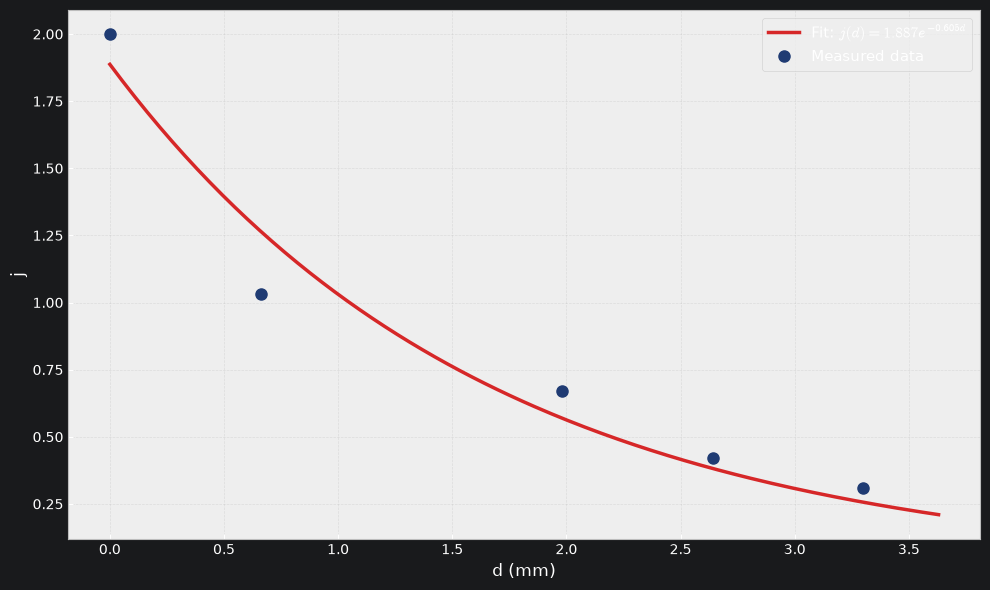

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use('bmh')

# Data storage
N = np.array([0, 1, 3, 4, 5])
j = np.array([2.0, 1.03, 0.67, 0.42, 0.31])
d = 0.66 * N  # mm

d_values = np.full_like(N, d, dtype=float)

print(f"N: {N}")
print(f"j: {j}")
print(f"d (mm): {d_values}")

def exponential_model(d, j0, mu):
    return j0 * np.exp(-mu * d)

try:
    params, cov = curve_fit(exponential_model, d_values, j, p0=[2.0, 0.5], maxfev=10000)
    j0, mu = params
    errors = np.sqrt(np.diag(cov))
    j0_err, mu_err = errors

    print(f"mu = {mu * 10:.4f} +- {mu_err * 10:.4f} 1/cm")

except Exception as e:
    print(f"✗ Fit failed: {e}")
    j0, mu = None, None

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(d_values, j,
            fmt='o',
            markersize=8,
            color='#1f3b73',
            elinewidth=2,
            capsize=5,
            capthick=2,
            linestyle='none',
            label='Measured data')

if j0 is not None and mu is not None:
    d_fit = np.linspace(0, max(d_values) * 1.1, 200)
    j_fit = exponential_model(d_fit, j0, mu)

    ax.plot(d_fit, j_fit,
            color='#d62728',
            linewidth=2.5,
            label=f'Fit: $j(d) = {j0:.3f}e^{{-{mu:.3f}d}}$')

ax.set_xlabel('d (mm)', fontsize=12)
ax.set_ylabel('j', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

absobcijski koeficient je $\mu = (6.0 \pm 1.0) 1/cm$